In [1]:
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain.tools import tool
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import HumanMessage, SystemMessage

from typing import TypedDict, Annotated

import operator

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()

# LLM

In [ ]:
llm = ChatOpenRouter(model='openrouter/owl-alpha',
                     api_key=os.getenv('OPENROUTER_API_KEY')) #type: ignore

# Tools

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

C:\Users\BRUH\AppData\Local\Temp\ipykernel_1692\1490969448.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [4]:
search_engine = DuckDuckGoSearchRun()

In [5]:
result = search_engine.invoke('Is AI in a bubble?', max_results=2)

In [6]:
@tool
def search_web(query: str, max_results: int = 2):
    """Search Internet using Duck Duck Go"""
    search_engine = DuckDuckGoSearchRun()
    return search_engine.invoke(query, max_results=max_results)

# State

In [7]:
class ReactState(TypedDict):
    messages: Annotated[list, add_messages]

# React Agent

In [8]:
llm_with_tools = llm.bind_tools([search_web])

In [9]:
def llm_node(state: ReactState):
    return {
        'messages': [llm_with_tools.invoke(state['messages'])]
    }

In [10]:
tools_node = ToolNode([search_web])

In [11]:
graph = StateGraph(ReactState)

#add nodes
graph.add_node('llm', llm_node)
graph.add_node('tools_node', tools_node)

#add edges
graph.add_edge(START, 'llm')
graph.add_conditional_edges(
    'llm',
    tools_condition,
    {
        'tools': 'tools_node',
        '__end__': END
    }
)
graph.add_edge('tools_node', 'llm')

react_agent = graph.compile()

# Display Graph

In [12]:
from IPython.display import display, Image
def display_graph(app):
    display(Image(app.get_graph().draw_mermaid_png()))

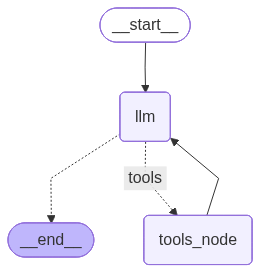

In [13]:
display_graph(react_agent)

In [14]:
response = react_agent.invoke({'messages': [HumanMessage('is viet nam economy fragile?')]})

In [15]:
response

{'messages': [HumanMessage(content='is viet nam economy fragile?', additional_kwargs={}, response_metadata={}, id='281cf1a0-e1b0-4456-a80c-403b7ba0d64d'),
  AIMessage(content="Vietnam's economy has shown significant resilience and growth over the past few decades, transforming from one of the poorest countries to a middle-income nation. While there have been historical periods of instability, the current economic fundamentals are generally considered stronger and more diverse than they have been in the past.\\\n\nKey aspects supporting Vietnam's economic strength include:\\\n- Consistent GDP growth rates, typically between 5-7% annually\\\n- Diverse manufacturing base and export economy\\\n- Growing domestic consumption market\\\n- Strategic position in global supply chains\\\n- Young and growing workforce\\\n\nHowever, like any emerging economy, Vietnam does face challenges including vulnerability to global economic shifts, infrastructure development needs, and the need to balance eco

# Planner

In [16]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

In [40]:
planner_prompt = ChatPromptTemplate.from_messages([
    ('system', """You are a planner. Break the task into clear sequential steps.
Return JSON only (example): {{"steps": ["step 1", "step 2", ...]}}"""),
    ('human', '{input}')
])
planner  = planner_prompt | llm | JsonOutputParser()

# Planning

In [41]:
class PlanExecuteState(TypedDict):
    task: str
    plans: list[str]
    finished_tasks: Annotated[list[str], operator.add]
    current_task_num: int
    response: str

In [42]:
def planning(state: PlanExecuteState):
    task = state['task']
    plans = planner.invoke({'input': task})
    return {'plans': plans}

In [43]:
def execute_task(state: PlanExecuteState):
    plans = state['plans']
    finished_tasks = '\n\n'.join(f'Plan {i}:\n{finished_task}' for i, finished_task in enumerate(state['finished_tasks'], start=1))
    current_task_num = state.get('current_task_num', 0)
    if current_task_num == 0:
        current_task = 'This is the first task.'
    else:
        current_task = plans[current_task_num]
    response = react_agent.invoke({'messages': [
        SystemMessage('You are a researcher, given current task and previous finished tasks, complete the current task. Only output report'),
        HumanMessage(f'''
         Finished task: {finished_tasks}
         
         Current task: {current_task}
         
         Report: 
         ''')
    ]})
    return {
        'finished_tasks': [response['messages'][-1].content],
        'current_task': current_task_num + 1,
    }

In [44]:
def router(state: PlanExecuteState):
    current_task_num = state.get('current_task_num', 0)
    finished_tasks = state.get('finished_task', [])
    if current_task_num == len(finished_tasks):
        return 'aggregator'
    return 'execute_plans'

In [45]:
def synthesize_tasks(state: PlanExecuteState):
    finished_tasks = '\n\n'.join(f'Plan {i} + {finished_task}' for i, finished_task in enumerate(state['finished_tasks'], start=1))
    response = llm.invoke([
        SystemMessage('you are a editor, given reports from all subtasks, synthesize to produce final report'),
        HumanMessage(f'''
         Original task: {state['task']}
         
         Finished task: {finished_tasks}
         
         Final report:
         ''')
    ])
    return {'response': response.content}

# Planning graph

In [49]:
planning_graph = StateGraph(PlanExecuteState)

#add nodes
planning_graph.add_node('Planning', planning)
planning_graph.add_node('Execute Plans', execute_task)
planning_graph.add_node('Aggregator', synthesize_tasks)

#add edges
planning_graph.add_edge(START, 'Planning')
planning_graph.add_edge('Planning', 'Execute Plans')
planning_graph.add_conditional_edges(
    'Execute Plans',
    router,
    {
        'aggregator': 'Aggregator',
        'execute_plans': 'Execute Plans'
    }
)
planning_graph.add_edge('Aggregator', END)
planning_app = planning_graph.compile()

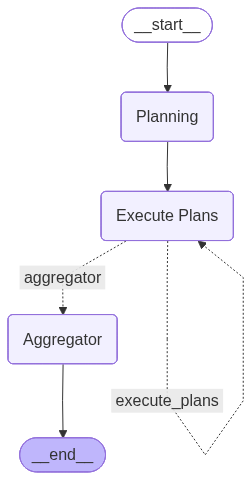

In [50]:
display_graph(planning_app)

In [51]:
final_state = planning_app.invoke({
    'task': 'Create a report about Viet Nam economy', #type: ignore
})

In [52]:
final_state

{'task': 'Create a report about Viet Nam economy',
 'plans': {'steps': ['Define the scope of the Vietnam economy report (macroeconomic indicators, key sectors, foreign investment, trends).',
   'Research and gather the latest data on GDP growth, inflation, trade balance, FDI inflows, and key industries (manufacturing, agriculture, services).',
   "Analyze the structure of Vietnam's economy and its transition from agriculture to manufacturing and services.",
   'Outline the report: Executive Summary, Economic Overview, Key Sectors, Foreign Investment, Challenges, and Future Outlook.',
   'Write the report based on the outline and collected data.',
   'Fact-check all figures and data for accuracy.',
   'Format the report professionally and add a title.']},
 'finished_tasks': ['### Report: Latest Advancements in Artificial Intelligence (2024)\n\n#### **Executive Summary**\nThe year 2024 has been marked by significant breakthroughs in artificial intelligence, characterized by enhanced mode

In [53]:
print(final_state['response'])

# Report: The Economy of Vietnam

## Overview

Vietnam has emerged as one of the fastest-growing economies in Southeast Asia, with significant growth driven by manufacturing, exports, and foreign direct investment. The country has positioned itself as a key player in global supply chains, benefiting from trade diversification and an increasingly skilled workforce.

---

## Key Economic Indicators (Latest Available Data)

### GDP Growth
| Indicator | 2022 | 2023 | 2024 (Est.) |
|-----------|------|------|---------------|
| GDP Growth Rate | 8.0% | 5.1% | ~6.5% |
| GDP (Nominal) | $408B | $430B | ~$476B |
| GDP Per Capita | $4,110 | $4,284 | ~$4,620 |

Vietnam's GDP growth rebounded strongly in 2024 after a slowdown in 2023 caused by global headwinds.

### Inflation

Annual consumer price inflation has been held at moderate levels:

| Year | Avg. CPI Inflation |
|------|-------------------|
| 2022 | 3.1% |
| 2023 | 3.2% |
| 2024 (Est.) | ~3.5% |

The State Bank of Vietnam (SBV) has kept 

# Report: The Economy of Vietnam

## Overview

Vietnam has emerged as one of the fastest-growing economies in Southeast Asia, with significant growth driven by manufacturing, exports, and foreign direct investment. The country has positioned itself as a key player in global supply chains, benefiting from trade diversification and an increasingly skilled workforce.

---

## Key Economic Indicators (Latest Available Data)

### GDP Growth
| Indicator | 2022 | 2023 | 2024 (Est.) |
|-----------|------|------|---------------|
| GDP Growth Rate | 8.0% | 5.1% | ~6.5% |
| GDP (Nominal) | $408B | $430B | ~$476B |
| GDP Per Capita | $4,110 | $4,284 | ~$4,620 |

Vietnam's GDP growth rebounded strongly in 2024 after a slowdown in 2023 caused by global headwinds.

### Inflation

Annual consumer price inflation has been held at moderate levels:

| Year | Avg. CPI Inflation |
|------|-------------------|
| 2022 | 3.1% |
| 2023 | 3.2% |
| 2024 (Est.) | ~3.5% |

The State Bank of Vietnam (SBV) has kept monetary policy accommodative to support economic recovery while maintaining price stability.

---

## Structural Drivers of Growth

### 1. Manufacturing & Exports
Vietnam continues to be a top destination for FDI inflows in ASEAN, particularly in electronics (Samsung, LG, Intel), textiles and garments, and furniture manufacturing. The country’s export value reached approximately $380B in 2024, with electronics and mobile phones accounting for the largest share. Trade agreements such as the CPTPP and EVFTA have further strengthened Vietnam's export competitiveness.

### 2. Foreign Direct Investment (FDI)
FDI disbursement hit a record high in 2024, reaching around $22B, reflecting investor confidence in Vietnam’s long-term prospects.

### 3. Domestic Consumption
Domestic consumption has steadily increased, supported by a growing middle class and rapid urbanization. The retail sector grew by approximately 9% year-over-year in 2024.

### 4. Digital Economy
Vietnam’s digital economy is one of the region’s fastest-growing, projected to reach $49B by 2025, driven by e-commerce, fintech, and ride-hailing services.

---

## Challenges and Risks

| Challenge | Details |
|-----------|---------|
| **Global Demand** | Persistent weak global demand can affect export performance |
| **CClimate Change** | Vietnam is among the most vulnerable nations to climate change, especially in the Mekong Delta |
| **Infrastructure** | Infrastructure bottlenecks remain in transport and logistics |
| **Labor Skills** | Despite a large workforce, there are gaps in advanced digital and technical skills |
| **Public Debt** | Fiscal pressure from stimulus packages and infrastructure investment needs |

---

## Outlook (2025 and Beyond)

Vietnam’s economy is projected to grow by 6.0–6.5% in 2025, supported by:
- Continued FDI inflows
- Expanding manufacturing base
- Robust domestic consumption
- Increasing digital adoption

The government aims to become a high-income nation by 2045, focusing on innovation, green energy transition, and institutional reforms.

---

## Conclusion

Vietnam's economy remains one of the most dynamic in Southeast Asia, supported by strong fundamentals including a young population, favorable trade agreements, and strategic geographic positioning. While challenges persist, the country is well-positioned for sustained growth in the coming years.